# Exploratory Data Analysis - Financial Fraud Detection

This notebook explores a publicly available credit card transaction dataset to understand the structure, distributions, and imbalance of fraudulent vs normal transactions. The goal of this analysis is to build intuition about the data before applying anomaly detection models such as Isolation Forest and Autoencoders.

# Importing Libaries to be used 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)


# Loading Dataset

In [2]:
df = pd.read_csv("creditcard_dataset.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Data Set Overview

In [3]:
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


The dataset contains PCA-transformed features (V1–V28), along with Time, Amount, and the binary target variable Class (0 = normal, 1 = fraud). No missing values are present.

# Shape Check

In [4]:
df.shape

(284807, 31)

# Missing Values

In [5]:
df.isnull().sum().sum()

0

# Fraud vs Normal Distribution

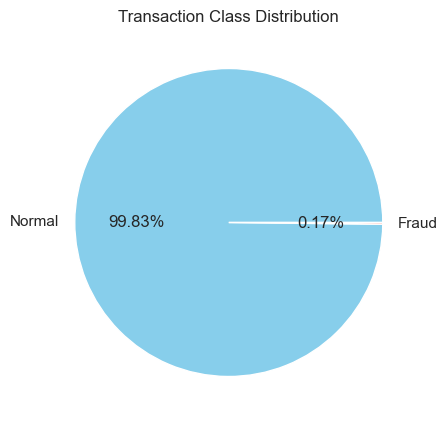

In [6]:
df['Class'].value_counts().plot.pie(
    labels=['Normal','Fraud'],
    autopct='%1.2f%%',
    colors=['skyblue','salmon']
)
plt.title("Transaction Class Distribution")
plt.ylabel("")
plt.show()


The dataset is extremely imbalanced, with fraudulent transactions representing less than 0.2% of all observations. This makes traditional classification approaches difficult and motivates the use of anomaly detection techniques, which focus on modelling normal behaviour and identifying deviations.

# Transaction Amount Distribution

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


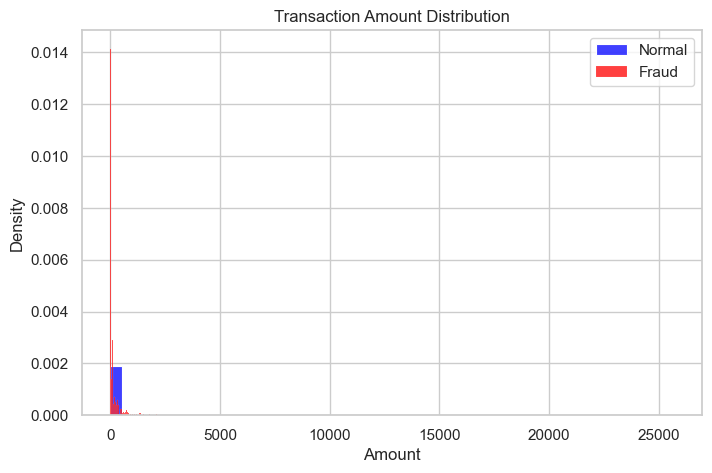

In [7]:
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='blue', label='Normal', stat='density')
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red', label='Fraud', stat='density')
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()


Fraudulent transactions show a different spread compared to normal transactions, indicating behavioural differences.

# Feature Differences

Although PCA-transformed features are anonymised, differences in their statistical distributions can reveal behavioural differences between fraudulent and normal transactions.

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


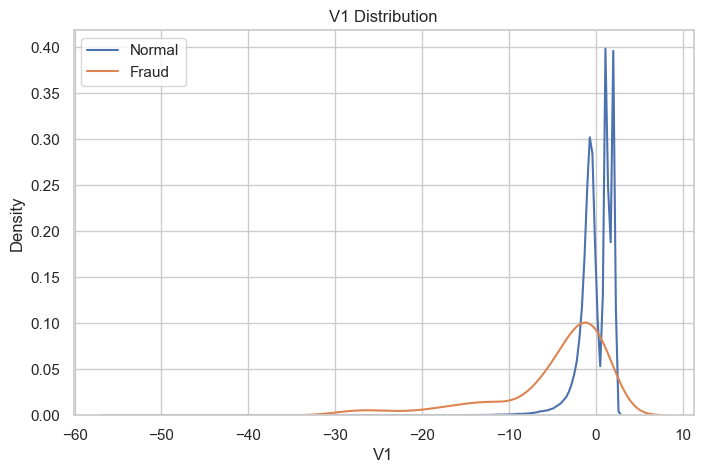

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


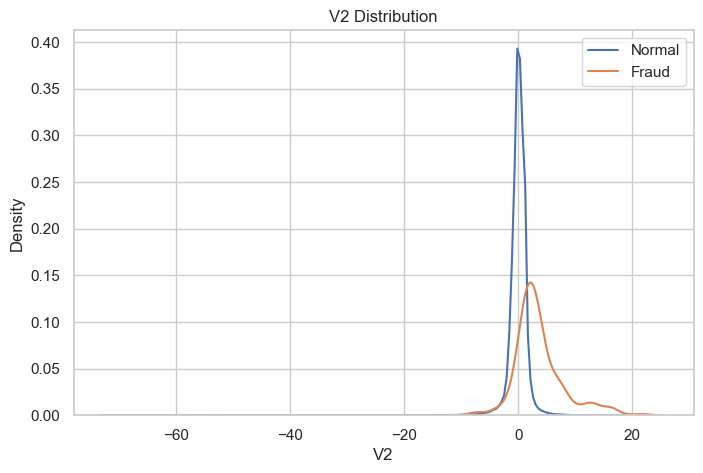

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


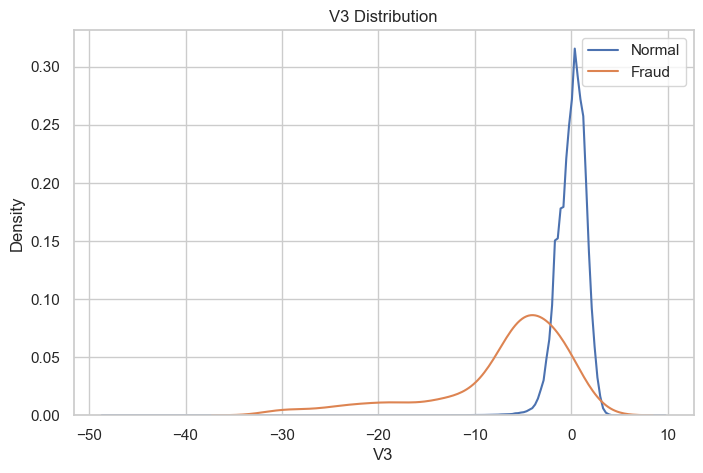

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


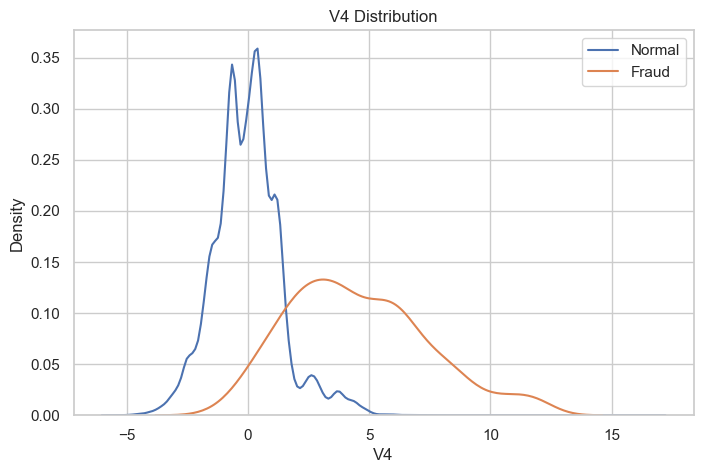

In [8]:
features = ['V1', 'V2', 'V3', 'V4']

for f in features:
    sns.kdeplot(df[df['Class']==0][f], label='Normal')
    sns.kdeplot(df[df['Class']==1][f], label='Fraud')
    plt.title(f"{f} Distribution")
    plt.legend()
    plt.show()


Fraudulent transactions occupy different regions of feature space compared to normal ones, supporting the use of anomaly detection methods.

# Identifying Features with the Largest Behavioural Differences



To better understand which features differ most between fraudulent and normal transactions, the mean value of each feature was calculated separately for the two classes. The absolute difference between these means was then used as a simple measure of how differently fraud behaves in each feature dimension.

Features with larger differences may contribute more strongly to separating anomalous behaviour from normal transactions. These features are therefore particularly important for anomaly detection models such as Isolation Forest and Autoencoders, which rely on identifying unusual patterns in high-dimensional space.

In [9]:
fraud_means = df[df['Class']==1].mean()
normal_means = df[df['Class']==0].mean()

diff = (fraud_means - normal_means).abs().sort_values(ascending=False)
diff.head(10)


Time      14091.395347
Amount       33.920299
V3            7.045452
V14           6.983787
V17           6.677371
V12           6.270225
V10           5.686707
V7            5.578368
V1            4.780206
V4            4.549889
dtype: float64

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


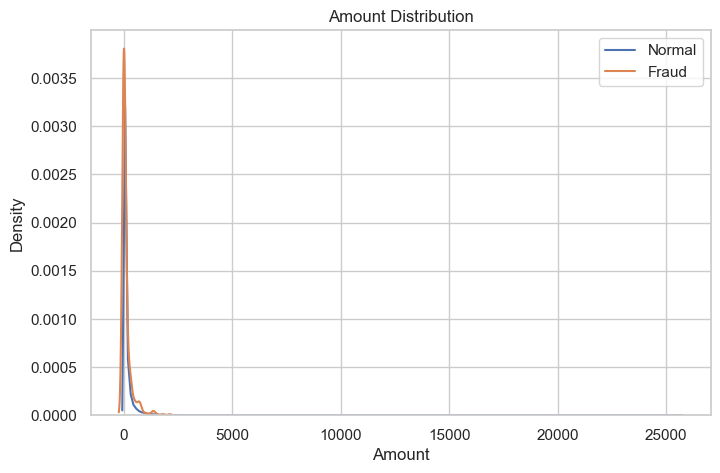

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


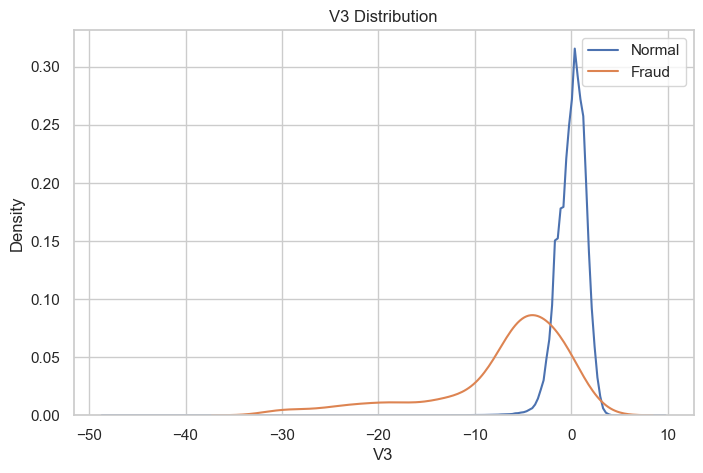

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


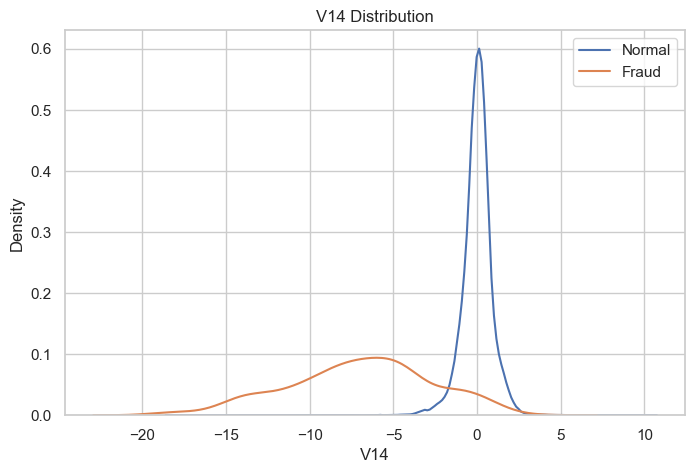

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


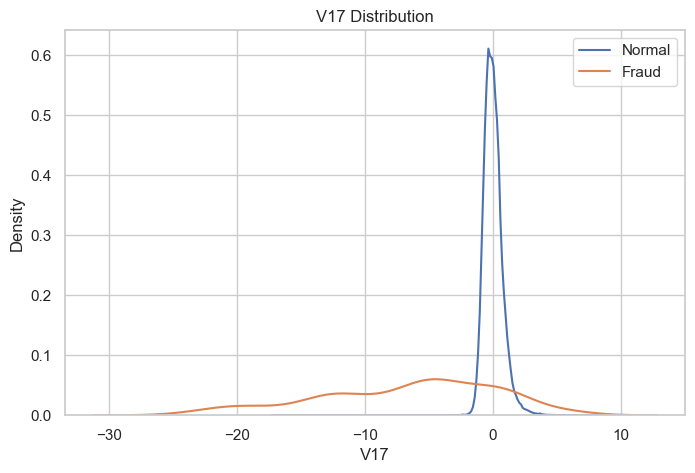

/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/radi/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


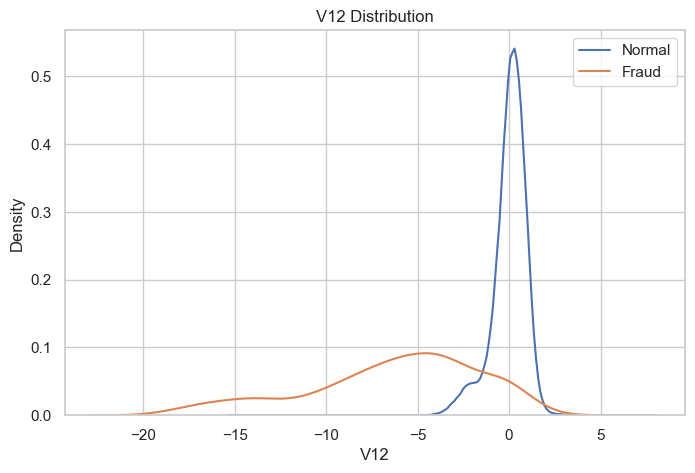

In [10]:
top_features = diff.index[1:6]  # skip Class

for f in top_features:
    sns.kdeplot(df[df['Class']==0][f], label='Normal')
    sns.kdeplot(df[df['Class']==1][f], label='Fraud')
    plt.title(f"{f} Distribution")
    plt.legend()
    plt.show()


Fraudulent transactions differ from normal ones across several feature dimensions, suggesting that anomaly detection models can identify fraud by learning the structure of normal behaviour and detecting deviations in feature space.

# Correlation Heatmap

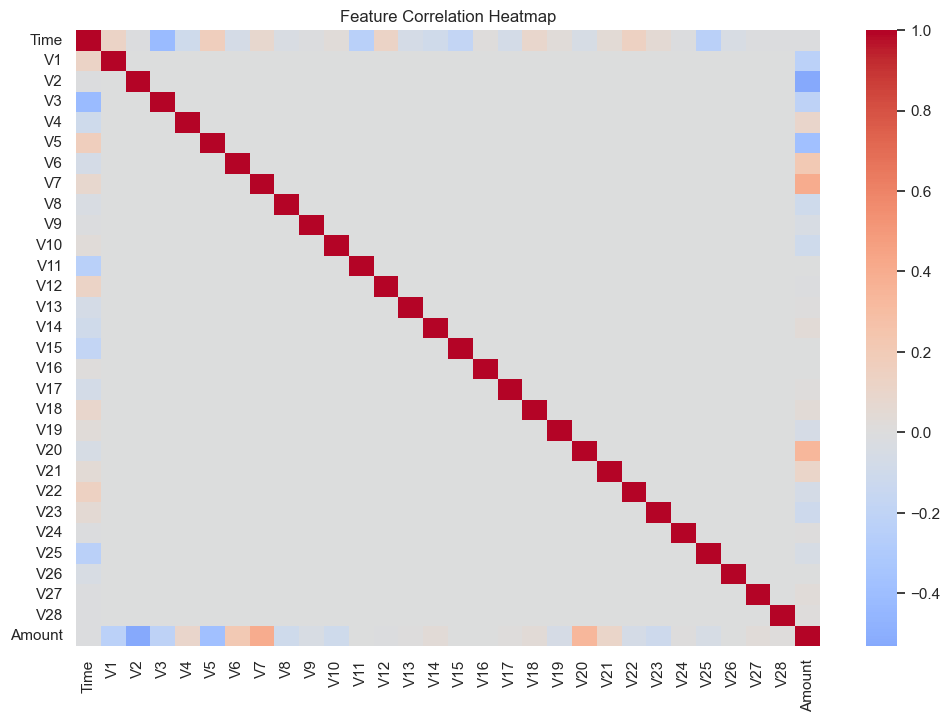

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.drop(columns=['Class']).corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


As expected from PCA-transformed features, most variables show low correlation, indicating reduced redundancy in the feature space.

# EDA Summary

Dataset contains anonymised PCA features with no missing values

Fraud is extremely rare (<0.2%), making anomaly detection appropriate

Fraudulent transactions differ statistically from normal ones across several features

Feature correlations are low due to PCA transformation

The data structure supports using models that learn “normal behaviour” and detect deviations